# Shop Fraud ML Pipeline

This notebook implements an end-to-end fraud prediction pipeline for `shop.db` with chapter-aligned methods from Chapters 1-27.

**Primary target:** `orders.is_fraud`  
**Goal:** maximize fraud capture while managing false positives.


## 1) Business Objective and Chapter Mapping (Ch 1-27)

### Business framing (Ch 1)
- Fraud detection is a **binary classification** task.
- False negatives are usually more expensive than false positives.
- Primary evaluation focus is **precision-recall tradeoff** because fraud is a minority class.

### Chapter-to-pipeline matrix
| Chapter(s) | Principle | How it is implemented here |
|---|---|---|
| 1 | CRISP-DM / project methodology | Problem framing, metrics, risk, acceptance criteria |
| 2-3 | DataFrames + wrangling | Table joins, type cleaning, date handling, vectorized features |
| 4 | Reading/Writing + SQLite | SQL extraction from `shop.db`, exportable artifacts |
| 5 | API retrieval concepts | Extension hook for optional external risk signals |
| 6 | Automated feature-level EDA | Univariate profiling and missingness diagnostics |
| 7 | Automated prep pipelines | sklearn `Pipeline` + `ColumnTransformer` |
| 8 | Relationship discovery | Fraud-rate relationships, Cramer's V, correlations |
| 9-11 | Linear model foundations + diagnostics | Logistic baseline and collinearity checks |
| 12 | Tree modeling concepts | Decision tree baseline with regularization |
| 13 | Classification modeling | Metrics, confusion matrix, threshold strategy |
| 14 | Ensemble methods | Random forest + gradient boosting |
| 15 | Model selection and tuning | Stratified CV + randomized search + holdout testing |
| 16 | Feature selection | Mutual information, L1 selection, permutation importance |
| 17 | Deploying pipelines | Model serialization and scoring function |
| 18 | Monitoring lifecycle | Drift/performance monitoring template |
| 19 | Forecasting | Fraud volume trend/forecast extension |
| 20 | Clustering | Fraud typology segmentation extension |
| 21-23 | NLP features | Review-text derived risk features extension |
| 24 | Image classification | Placeholder for image-return fraud use case |
| 25-26 | Recommender concepts | Behavior deviation features extension |
| 27 | Final project standards | Reproducibility, model card, deliverable structure |


In [1]:
# Core imports and reproducibility
import os
import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
except Exception:
    sns = None

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import mutual_info_classif, SelectFromModel
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
np.random.seed(42)

BASE_DIR = Path('/Users/marycatherineshepherd/Documents/455')
DB_PATH = BASE_DIR / 'shop.db'
ARTIFACT_DIR = BASE_DIR / 'artifacts'
ARTIFACT_DIR.mkdir(exist_ok=True)

print('Database exists:', DB_PATH.exists())
print('Artifact directory:', ARTIFACT_DIR)


Database exists: True
Artifact directory: /Users/marycatherineshepherd/Documents/455/artifacts


## 2) Data Extraction from SQLite (Ch 2-5)
This section builds an order-level analytic table by joining transactional, customer, and shipment data, plus item-level aggregates.


In [2]:
# Order-level SQL extraction (Ch 4: SQLite I/O)
base_sql = """
WITH item_agg AS (
    SELECT
        oi.order_id,
        COUNT(*) AS line_count,
        SUM(oi.quantity) AS total_quantity,
        SUM(oi.line_total) AS item_line_total,
        AVG(oi.unit_price) AS avg_unit_price,
        MAX(oi.unit_price) AS max_unit_price,
        COUNT(DISTINCT oi.product_id) AS distinct_products
    FROM order_items oi
    GROUP BY oi.order_id
)
SELECT
    o.order_id,
    o.customer_id,
    o.order_datetime,
    o.billing_zip,
    o.shipping_zip,
    o.shipping_state,
    o.payment_method,
    o.device_type,
    o.ip_country,
    o.promo_used,
    o.order_subtotal,
    o.shipping_fee,
    o.tax_amount,
    o.order_total,
    o.risk_score,
    o.is_fraud,
    c.gender,
    c.birthdate,
    c.created_at AS customer_created_at,
    c.city,
    c.state AS customer_state,
    c.customer_segment,
    c.loyalty_tier,
    c.is_active,
    s.carrier,
    s.shipping_method,
    s.distance_band,
    s.promised_days,
    s.actual_days,
    s.late_delivery,
    ia.line_count,
    ia.total_quantity,
    ia.item_line_total,
    ia.avg_unit_price,
    ia.max_unit_price,
    ia.distinct_products
FROM orders o
LEFT JOIN customers c ON o.customer_id = c.customer_id
LEFT JOIN shipments s ON o.order_id = s.order_id
LEFT JOIN item_agg ia ON o.order_id = ia.order_id
"""

with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql_query(base_sql, conn)

print('Shape:', df.shape)
df.head(3)


Shape: (5000, 36)


,order_id,customer_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,...,distance_band,promised_days,actual_days,late_delivery,line_count,total_quantity,item_line_total,avg_unit_price,max_unit_price,distinct_products
0,1,1,2025-11-29 00:51:07,28289,28289,CO,card,mobile,US,0,...,regional,3,5,1,5,9,662.95,69.242,99.90,5
1,2,1,2025-09-01 10:25:59,28289,13888,NY,card,desktop,US,1,...,local,2,3,1,5,7,862.92,133.300,241.51,5
2,3,1,2025-12-15 07:24:41,28289,28289,CO,card,mobile,US,0,...,national,4,8,1,3,5,796.09,140.850,230.50,3


Fraud prevalence: 6.36% (318 / 5000)


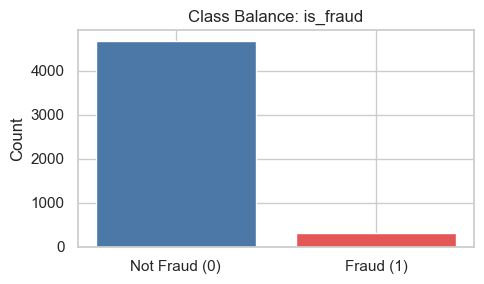

In [3]:
# Quick target balance check
fraud_rate = df['is_fraud'].mean()
print(f"Fraud prevalence: {fraud_rate:.2%} ({df['is_fraud'].sum()} / {len(df)})")

fig, ax = plt.subplots(figsize=(5, 3))
counts = df['is_fraud'].value_counts().sort_index()
ax.bar(['Not Fraud (0)', 'Fraud (1)'], counts.values, color=['#4C78A8', '#E45756'])
ax.set_title('Class Balance: is_fraud')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


## 3) Order-Level Dataset Build and Feature Engineering (Ch 3, 7)

We convert raw fields into model-ready predictors while guarding against leakage.


In [4]:
def build_features(raw: pd.DataFrame) -> pd.DataFrame:
    data = raw.copy()

    # Datetime conversion
    dt_cols = ['order_datetime', 'customer_created_at', 'birthdate']
    for c in dt_cols:
        data[c] = pd.to_datetime(data[c], errors='coerce')

    # Time-based features
    data['order_hour'] = data['order_datetime'].dt.hour
    data['order_dayofweek'] = data['order_datetime'].dt.dayofweek
    data['order_month'] = data['order_datetime'].dt.month
    data['is_weekend_order'] = data['order_dayofweek'].isin([5, 6]).astype(int)

    # Customer lifecycle features
    data['customer_tenure_days'] = (data['order_datetime'] - data['customer_created_at']).dt.days
    data['customer_age_years'] = ((data['order_datetime'] - data['birthdate']).dt.days / 365.25)

    # Shipping / address mismatch features
    data['zip_mismatch'] = (
        data['billing_zip'].fillna('').astype(str).str[:5] !=
        data['shipping_zip'].fillna('').astype(str).str[:5]
    ).astype(int)
    data['state_mismatch'] = (
        data['shipping_state'].fillna('').astype(str) !=
        data['customer_state'].fillna('').astype(str)
    ).astype(int)

    # Monetary and basket features
    data['shipping_to_subtotal_ratio'] = data['shipping_fee'] / (data['order_subtotal'].replace(0, np.nan))
    data['tax_to_subtotal_ratio'] = data['tax_amount'] / (data['order_subtotal'].replace(0, np.nan))
    data['avg_item_value_proxy'] = data['order_subtotal'] / (data['total_quantity'].replace(0, np.nan))
    data['high_ticket_order'] = (data['order_total'] > data['order_total'].quantile(0.90)).astype(int)

    # Shipment performance
    data['shipping_delay_days'] = data['actual_days'] - data['promised_days']

    # Customer order-history velocity features (calculated using prior orders only)
    data = data.sort_values(['customer_id', 'order_datetime']).reset_index(drop=True)
    data['customer_prior_order_count'] = data.groupby('customer_id').cumcount()
    data['customer_prior_avg_total'] = (
        data.groupby('customer_id')['order_total']
        .transform(lambda s: s.shift(1).expanding().mean())
    )
    data['customer_prior_total_std'] = (
        data.groupby('customer_id')['order_total']
        .transform(lambda s: s.shift(1).expanding().std())
    )

    # Rare combo signal: payment-device-country
    data['pay_dev_ctry'] = (
        data['payment_method'].fillna('NA').astype(str) + '__' +
        data['device_type'].fillna('NA').astype(str) + '__' +
        data['ip_country'].fillna('NA').astype(str)
    )
    combo_freq = data['pay_dev_ctry'].value_counts(normalize=True)
    data['pay_dev_ctry_freq'] = data['pay_dev_ctry'].map(combo_freq)
    data['rare_combo_flag'] = (data['pay_dev_ctry_freq'] < 0.01).astype(int)

    # Missing numeric stabilizers
    for c in ['customer_tenure_days', 'customer_age_years', 'shipping_delay_days', 'shipping_to_subtotal_ratio', 'tax_to_subtotal_ratio', 'avg_item_value_proxy', 'customer_prior_avg_total', 'customer_prior_total_std']:
        data[c] = data[c].replace([np.inf, -np.inf], np.nan)

    return data

feat_df = build_features(df)
feat_df.head(3)


,order_id,customer_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,...,tax_to_subtotal_ratio,avg_item_value_proxy,high_ticket_order,shipping_delay_days,customer_prior_order_count,customer_prior_avg_total,customer_prior_total_std,pay_dev_ctry,pay_dev_ctry_freq,rare_combo_flag
0,593,1,2025-07-09 22:19:28,28289,28289,CO,crypto,mobile,US,0,...,0.076647,94.094,0,1,0,NaN,NaN,crypto__mobile__US,0.0100,0
1,913,1,2025-07-09 23:46:32,28289,28289,CO,paypal,mobile,US,0,...,0.092541,103.630,0,0,1,514.570,NaN,paypal__mobile__US,0.1056,0
2,903,1,2025-07-10 02:53:00,28289,28289,CO,paypal,mobile,US,0,...,0.061591,76.310,0,-1,2,544.355,42.122351,paypal__mobile__US,0.1056,0


In [5]:
# Ch 6 automated feature-level exploration
profile = pd.DataFrame({
    'dtype': feat_df.dtypes.astype(str),
    'missing_pct': feat_df.isna().mean().mul(100).round(2),
    'n_unique': feat_df.nunique(dropna=False)
}).sort_values(['missing_pct', 'n_unique'], ascending=[False, False])

profile.head(20)


,dtype,missing_pct,n_unique
customer_prior_total_std,float64,9.24,4539
customer_prior_avg_total,float64,4.86,4757
order_id,int64,0.00,5000
order_datetime,datetime64[us],0.00,5000
tax_to_subtotal_ratio,float64,0.00,4976
order_total,float64,0.00,4857
shipping_to_subtotal_ratio,float64,0.00,4146
item_line_total,float64,0.00,4111
order_subtotal,float64,0.00,4077
avg_item_value_proxy,float64,0.00,4014


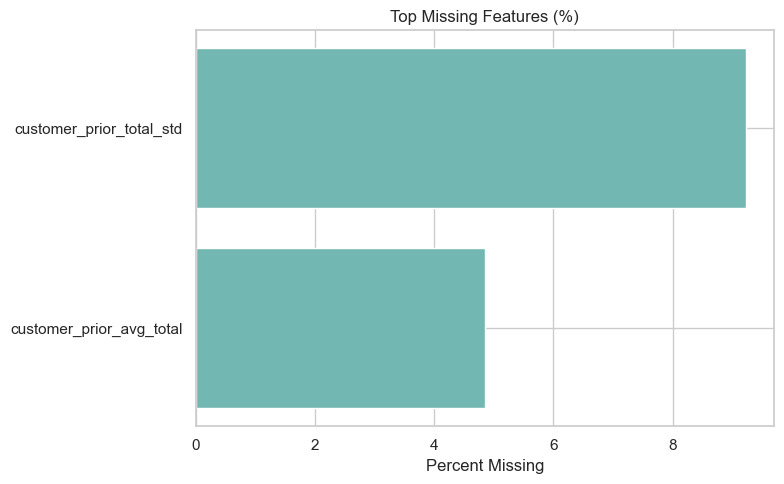

In [6]:
# Missingness visualization
missing_pct = feat_df.isna().mean().sort_values(ascending=False)
plot_series = missing_pct[missing_pct > 0].head(20)

if len(plot_series) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(plot_series.index[::-1], (plot_series.values[::-1] * 100), color='#72B7B2')
    ax.set_title('Top Missing Features (%)')
    ax.set_xlabel('Percent Missing')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values detected.')


## 4) Relationship Discovery (Ch 8)

We examine target-conditioned relationships to prioritize predictive features and spot risk patterns.


,fraud_rate,count
payment_method,,
crypto,0.103093,97
card,0.067455,3128
bank,0.059310,725
paypal,0.051429,1050


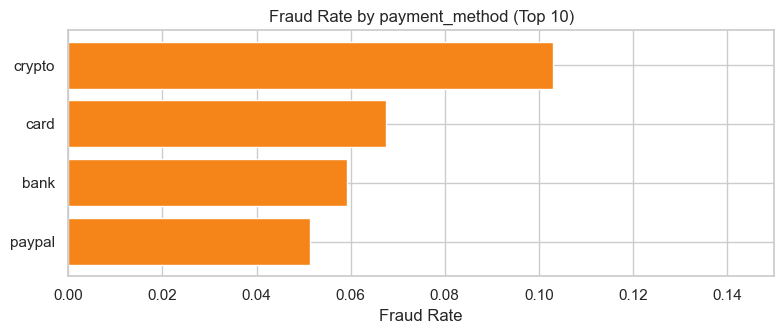

,fraud_rate,count
device_type,,
mobile,0.068032,2734
tablet,0.065934,364
desktop,0.056782,1902


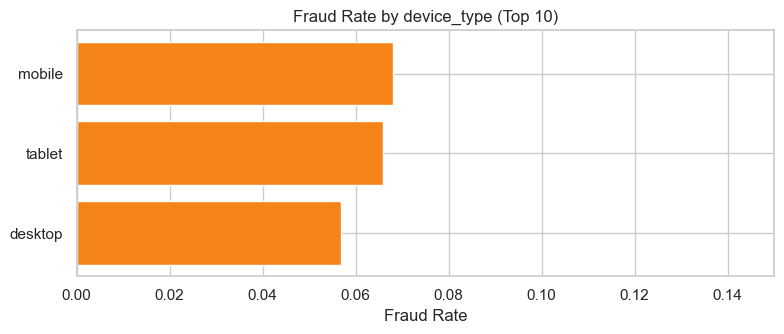

,fraud_rate,count
ip_country,,
IN,0.094737,95
GB,0.086538,104
BR,0.073171,41
CA,0.068807,218
NG,0.065217,46
US,0.062055,4496


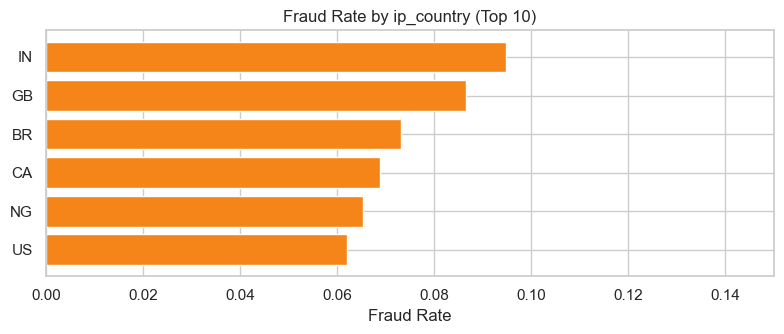

,fraud_rate,count
customer_segment,,
standard,0.067128,2890
budget,0.062358,1764
premium,0.040462,346


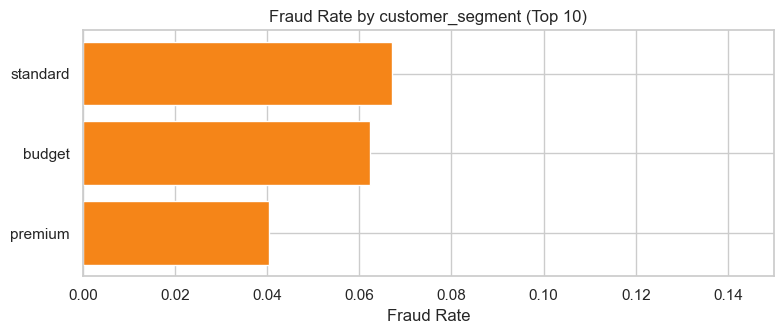

,fraud_rate,count
loyalty_tier,,
silver,0.073423,2220
none,0.062176,1930
gold,0.041176,850


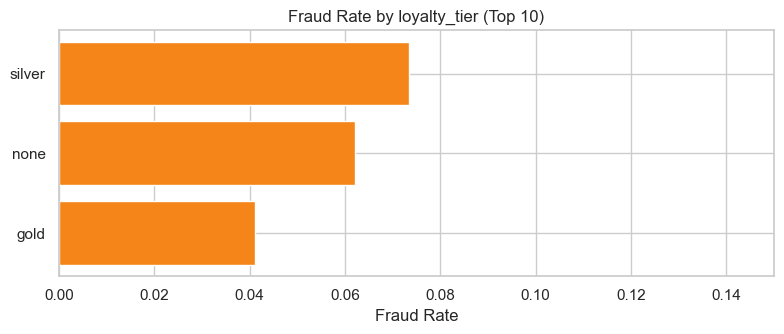

,fraud_rate,count
shipping_method,,
overnight,0.079208,303
standard,0.063847,3618
expedited,0.058387,1079


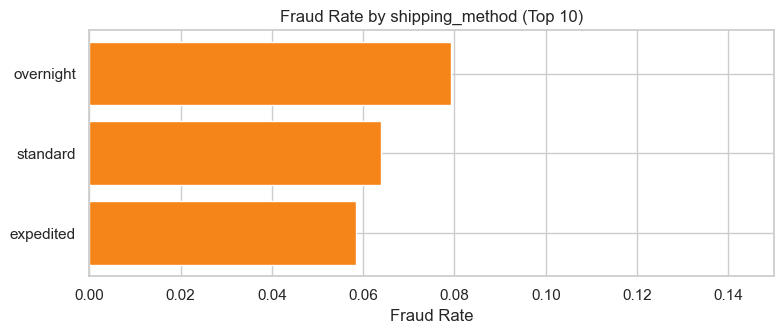

In [7]:
# Fraud rate by key categorical dimensions
cat_checks = ['payment_method', 'device_type', 'ip_country', 'customer_segment', 'loyalty_tier', 'shipping_method']

for c in cat_checks:
    tmp = (
        feat_df.groupby(c, dropna=False)['is_fraud']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'fraud_rate'})
        .sort_values('fraud_rate', ascending=False)
    )
    display(tmp.head(10))

    fig, ax = plt.subplots(figsize=(8, 3.5))
    top = tmp.head(10).iloc[::-1]
    ax.barh(top.index.astype(str), top['fraud_rate'], color='#F58518')
    ax.set_xlim(0, max(0.15, float(top['fraud_rate'].max()) * 1.15))
    ax.set_title(f'Fraud Rate by {c} (Top 10)')
    ax.set_xlabel('Fraud Rate')
    plt.tight_layout()
    plt.show()


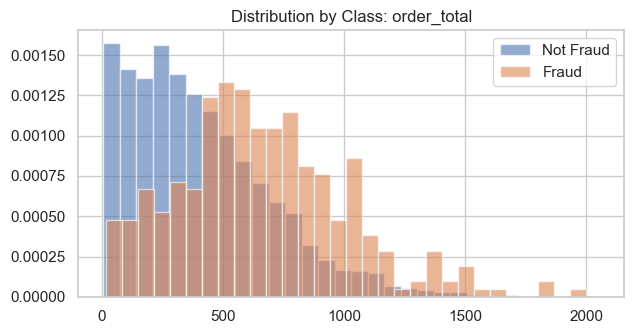

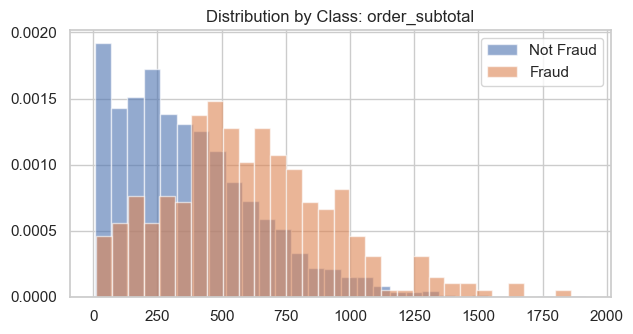

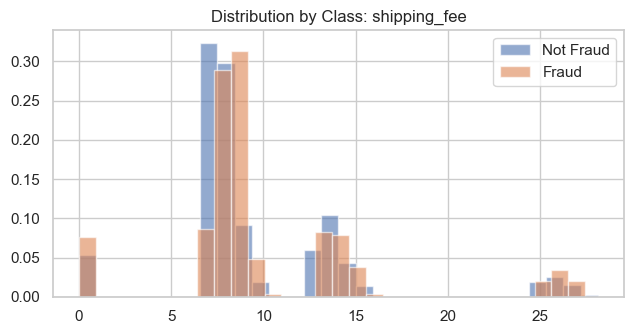

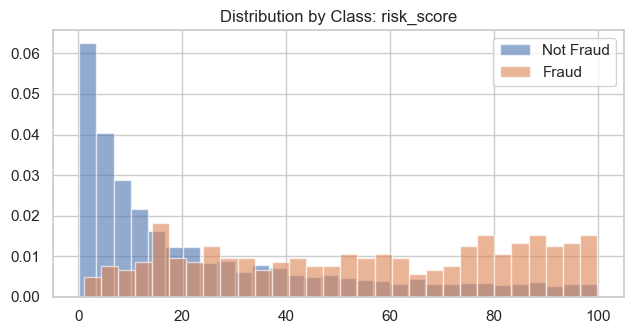

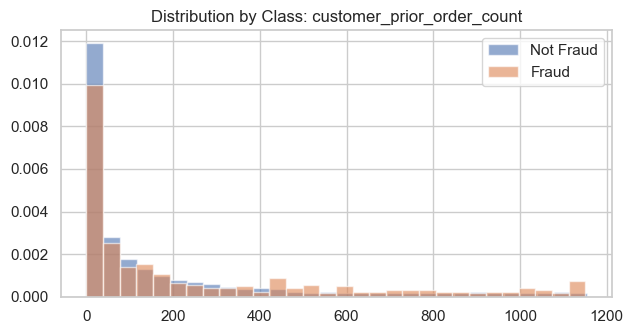

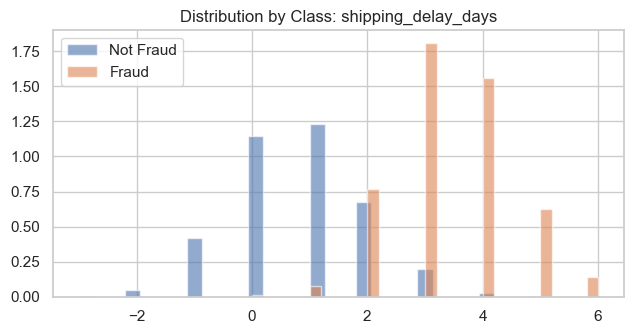

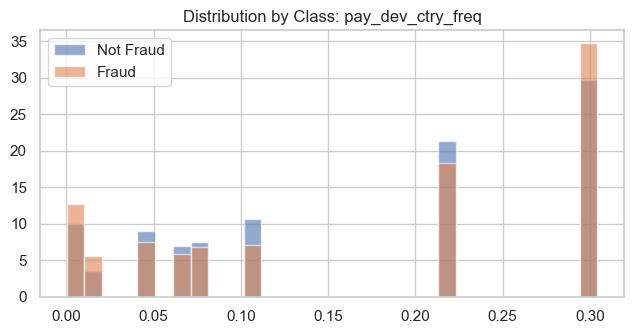

In [8]:
# Numeric relationship snapshots
num_cols_for_plot = ['order_total', 'order_subtotal', 'shipping_fee', 'risk_score', 'customer_prior_order_count', 'shipping_delay_days', 'pay_dev_ctry_freq']

for c in num_cols_for_plot:
    if c not in feat_df.columns:
        continue
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    non_null = feat_df[[c, 'is_fraud']].dropna()
    ax.hist(non_null.loc[non_null['is_fraud'] == 0, c], bins=30, alpha=0.6, label='Not Fraud', density=True)
    ax.hist(non_null.loc[non_null['is_fraud'] == 1, c], bins=30, alpha=0.6, label='Fraud', density=True)
    ax.set_title(f'Distribution by Class: {c}')
    ax.legend()
    plt.tight_layout()
    plt.show()


## 5) Modeling Dataset and Preprocessing Pipeline (Ch 7, 11)

We define train/test split strategy, feature sets, and a reusable preprocessing pipeline.


In [9]:
# Keep a modeling copy sorted by time to support leakage-aware holdout
model_df = feat_df.sort_values('order_datetime').copy()

# Drop obvious IDs and leakage-prone fields
drop_cols = [
    'order_id', 'customer_id', 'order_datetime', 'birthdate', 'customer_created_at',
    'pay_dev_ctry',  # replaced with frequency and rare flag
]

target_col = 'is_fraud'
feature_df = model_df.drop(columns=[c for c in drop_cols if c in model_df.columns])

# Separate X/y
X = feature_df.drop(columns=[target_col])
y = feature_df[target_col].astype(int)

# Temporal holdout: final 20% by time
split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx].copy(), X.iloc[split_idx:].copy()
y_train, y_test = y.iloc[:split_idx].copy(), y.iloc[split_idx:].copy()

print('Train size:', X_train.shape, 'Test size:', X_test.shape)
print('Train fraud rate:', y_train.mean().round(4), 'Test fraud rate:', y_test.mean().round(4))


Train size: (4000, 48) Test size: (1000, 48)
Train fraud rate: 0.067 Test fraud rate: 0.05


In [10]:
# Column typing for preprocessing
numeric_features = X_train.select_dtypes(include=['number', 'bool']).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=['number', 'bool']).columns.tolist()

print('Numeric features:', len(numeric_features))
print('Categorical features:', len(categorical_features))

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features)
])


Numeric features: 34
Categorical features: 14


## 6) Baseline Models (Ch 9-13)


In [11]:
# Baseline model set: interpretable + tree
models = {
    'logistic': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'decision_tree': DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, class_weight='balanced', random_state=42),
    'random_forest': RandomForestClassifier(n_estimators=300, min_samples_leaf=10, class_weight='balanced_subsample', random_state=42, n_jobs=-1),
    'gradient_boosting': GradientBoostingClassifier(random_state=42),
}

results = []
fitted = {}

for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    ap = average_precision_score(y_test, proba)
    roc = roc_auc_score(y_test, proba)

    results.append({'model': name, 'pr_auc': ap, 'roc_auc': roc})
    fitted[name] = {'pipe': pipe, 'proba': proba, 'pred': pred}

results_df = pd.DataFrame(results).sort_values('pr_auc', ascending=False)
results_df


,model,pr_auc,roc_auc
3,gradient_boosting,0.865735,0.984674
0,logistic,0.669183,0.956779
1,decision_tree,0.642225,0.882021
2,random_forest,0.396883,0.914653


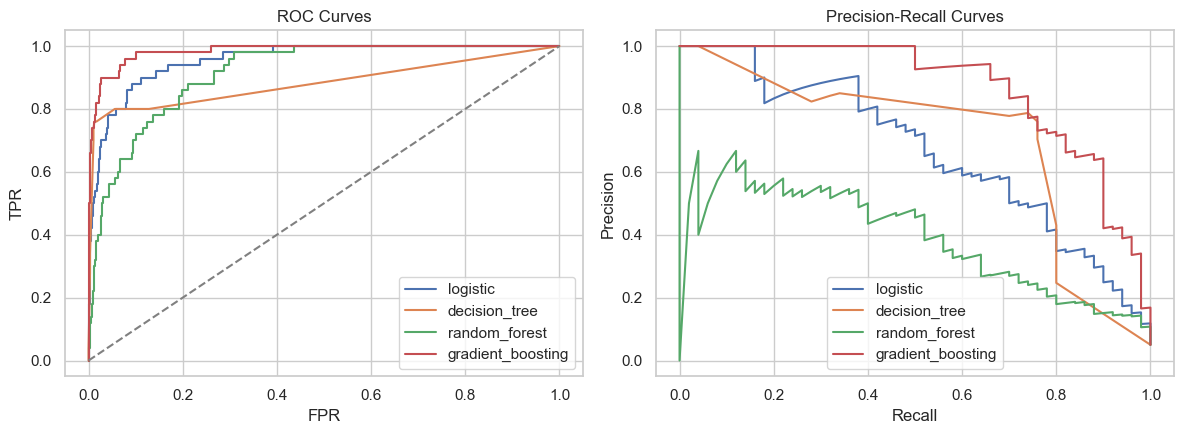

In [12]:
# ROC/PR curves for all baseline models
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for name, obj in fitted.items():
    proba = obj['proba']
    fpr, tpr, _ = roc_curve(y_test, proba)
    p, r, _ = precision_recall_curve(y_test, proba)

    axes[0].plot(fpr, tpr, label=name)
    axes[1].plot(r, p, label=name)

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('ROC Curves')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].legend()

axes[1].set_title('Precision-Recall Curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.show()


## 7) Model Tuning and Selection (Ch 14-15)


In [13]:
# Tune two stronger candidates with stratified CV on training split
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced_subsample', random_state=42, n_jobs=-1))
])

rf_params = {
    'model__n_estimators': [200, 300, 500],
    'model__max_depth': [None, 8, 12, 16],
    'model__min_samples_leaf': [5, 10, 20],
    'model__max_features': ['sqrt', 'log2', 0.5],
}

rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=rf_params,
    n_iter=12,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=0,
)

rf_search.fit(X_train, y_train)
print('Best RF CV PR-AUC:', round(rf_search.best_score_, 4))
print('Best RF params:', rf_search.best_params_)


Best RF CV PR-AUC: 0.8624
Best RF params: {'model__n_estimators': 200, 'model__min_samples_leaf': 5, 'model__max_features': 0.5, 'model__max_depth': 8}


In [14]:
gb_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])

gb_params = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__max_depth': [2, 3, 4],
    'model__min_samples_leaf': [10, 20, 30],
    'model__subsample': [0.7, 0.9, 1.0],
}

gb_search = RandomizedSearchCV(
    gb_pipe,
    param_distributions=gb_params,
    n_iter=12,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=0,
)

gb_search.fit(X_train, y_train)
print('Best GB CV PR-AUC:', round(gb_search.best_score_, 4))
print('Best GB params:', gb_search.best_params_)


Best GB CV PR-AUC: 0.8897
Best GB params: {'model__subsample': 0.7, 'model__n_estimators': 300, 'model__min_samples_leaf': 10, 'model__max_depth': 2, 'model__learning_rate': 0.03}


In [15]:
# Compare tuned finalists on temporal holdout
finalists = {
    'rf_tuned': rf_search.best_estimator_,
    'gb_tuned': gb_search.best_estimator_,
    'logistic_baseline': fitted['logistic']['pipe'],
}

final_results = []
final_probs = {}

for name, est in finalists.items():
    proba = est.predict_proba(X_test)[:, 1]
    ap = average_precision_score(y_test, proba)
    roc = roc_auc_score(y_test, proba)
    final_results.append({'model': name, 'pr_auc': ap, 'roc_auc': roc})
    final_probs[name] = proba

final_results_df = pd.DataFrame(final_results).sort_values('pr_auc', ascending=False)
final_results_df


,model,pr_auc,roc_auc
1,gb_tuned,0.898234,0.988968
0,rf_tuned,0.782177,0.975368
2,logistic_baseline,0.669183,0.956779


## 8) Feature Selection and Interpretation (Ch 16)


In [16]:
# Feature-space extraction from best model for interpretation
best_model_name = final_results_df.iloc[0]['model']
best_est = finalists[best_model_name]

prep = best_est.named_steps['prep']
X_train_t = prep.transform(X_train)
X_test_t = prep.transform(X_test)
feature_names = prep.get_feature_names_out()

# Filter method: mutual information ranking
mi = mutual_info_classif(X_train_t, y_train, random_state=42)
mi_df = pd.DataFrame({'feature': feature_names, 'mutual_info': mi}).sort_values('mutual_info', ascending=False)
mi_df.head(20)


,feature,mutual_info
25,num__tax_to_subtotal_ratio,0.245809
4,num__order_total,0.243383
12,num__item_line_total,0.233531
1,num__order_subtotal,0.233184
30,num__customer_prior_avg_total,0.231183
26,num__avg_item_value_proxy,0.227992
13,num__avg_unit_price,0.226759
31,num__customer_prior_total_std,0.223350
24,num__shipping_to_subtotal_ratio,0.222667
3,num__tax_amount,0.208448


In [17]:
# Embedded method: L1 logistic select-from-model on transformed space
l1 = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    class_weight='balanced',
    random_state=42,
    max_iter=2000,
)
l1.fit(X_train_t, y_train)
selector = SelectFromModel(l1, prefit=True)
selected_mask = selector.get_support()
selected_features = pd.Series(feature_names[selected_mask])

print('Selected features (L1):', len(selected_features))
selected_features.head(20)


Selected features (L1): 94


0                     num__promo_used
1                   num__shipping_fee
2                     num__tax_amount
3                     num__risk_score
4                  num__promised_days
5                  num__late_delivery
6                     num__line_count
7                 num__total_quantity
8                 num__avg_unit_price
9                 num__max_unit_price
10             num__distinct_products
11                    num__order_hour
12               num__order_dayofweek
13                   num__order_month
14              num__is_weekend_order
15          num__customer_tenure_days
16            num__customer_age_years
17                  num__zip_mismatch
18                num__state_mismatch
19    num__shipping_to_subtotal_ratio
dtype: str

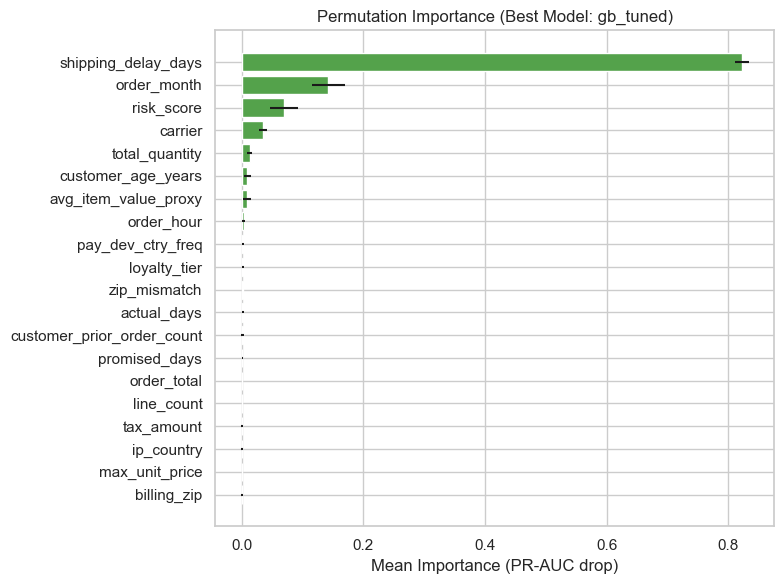

,feature,importance_mean,importance_std
42,shipping_delay_days,0.821512,0.011598
32,order_month,0.142243,0.027241
11,risk_score,0.069996,0.023159
18,carrier,0.034665,0.006608
25,total_quantity,0.012733,0.004629
35,customer_age_years,0.009109,0.006311
40,avg_item_value_proxy,0.008452,0.007133
30,order_hour,0.002844,0.003048
46,pay_dev_ctry_freq,0.001910,0.000869
16,loyalty_tier,0.001813,0.001084


In [18]:
# Permutation importance on holdout for best model
perm = permutation_importance(
    best_est,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='average_precision',
)
perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)

top_perm = perm_df.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_perm['feature'], top_perm['importance_mean'], xerr=top_perm['importance_std'], color='#54A24B')
ax.set_title(f'Permutation Importance (Best Model: {best_model_name})')
ax.set_xlabel('Mean Importance (PR-AUC drop)')
plt.tight_layout()
plt.show()

perm_df.head(15)


## 9) Threshold Strategy and Business Policy (Ch 13, 15, 18)

We convert probabilities to actions using threshold-based operating points.


In [19]:
best_proba = final_probs[best_model_name]
precision, recall, thresholds = precision_recall_curve(y_test, best_proba)

# Remove final point mismatch (thresholds has len-1)
pr_df = pd.DataFrame({
    'threshold': thresholds,
    'precision': precision[:-1],
    'recall': recall[:-1],
})

# Policy candidates
strict = pr_df[pr_df['precision'] >= 0.80].sort_values('recall', ascending=False).head(1)
balanced = pr_df.iloc[(pr_df['precision'] - pr_df['recall']).abs().argsort()[:1]]
aggressive = pr_df[pr_df['recall'] >= 0.70].sort_values('precision', ascending=False).head(1)

policy = pd.concat([
    strict.assign(policy='strict_high_precision'),
    balanced.assign(policy='balanced'),
    aggressive.assign(policy='aggressive_high_recall')
], ignore_index=True)

policy[['policy', 'threshold', 'precision', 'recall']]


,policy,threshold,precision,recall
0,strict_high_precision,0.223019,0.803922,0.82
1,balanced,0.224627,0.800000,0.80
2,aggressive_high_recall,0.586314,0.945946,0.70


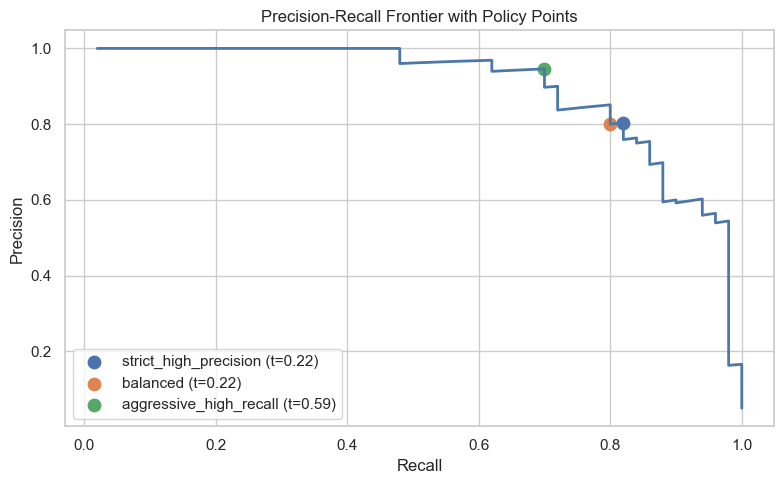

In [20]:
# Visualize threshold frontier and selected policies
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pr_df['recall'], pr_df['precision'], color='#4C78A8', linewidth=2)

for _, row in policy.iterrows():
    ax.scatter(row['recall'], row['precision'], s=80, label=f"{row['policy']} (t={row['threshold']:.2f})")

ax.set_title('Precision-Recall Frontier with Policy Points')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend()
plt.tight_layout()
plt.show()


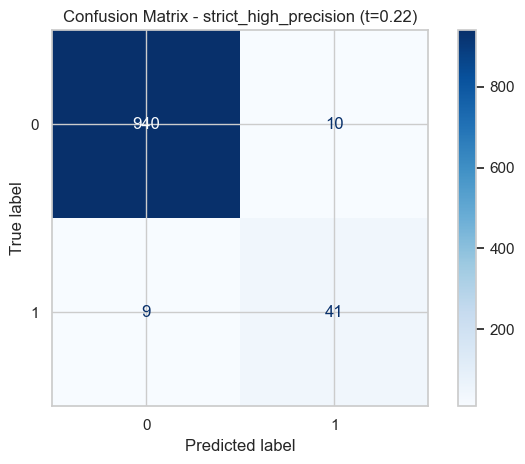

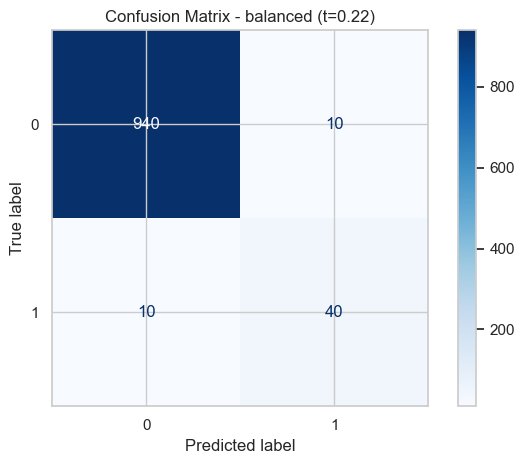

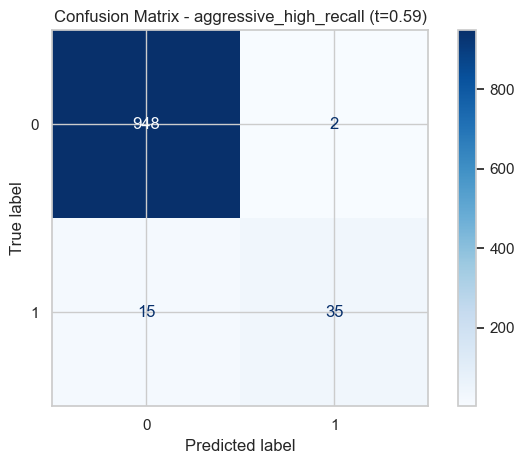

In [21]:
# Confusion matrices for each policy point
from sklearn.metrics import ConfusionMatrixDisplay

for _, row in policy.iterrows():
    t = float(row['threshold'])
    pred = (best_proba >= t).astype(int)
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix - {row['policy']} (t={t:.2f})")
    plt.tight_layout()
    plt.show()


## 10) Final Model Packaging and Batch Scoring (Ch 17)


In [22]:
import joblib

# Pick a policy threshold robustly, even if a named policy row is missing.
chosen_policy = 'balanced'
if 'policy' in policy.columns and 'threshold' in policy.columns and (policy['policy'] == chosen_policy).any():
    chosen_threshold = float(policy.loc[policy['policy'] == chosen_policy, 'threshold'].iloc[0])
elif 'threshold' in policy.columns and len(policy) > 0:
    chosen_threshold = float(policy['threshold'].iloc[0])
else:
    chosen_threshold = 0.5

bundle = {
    'model_name': best_model_name,
    'estimator': best_est,
    'threshold': chosen_threshold,
    'feature_columns': X_train.columns.tolist(),
    'created_utc': pd.Timestamp.utcnow().isoformat(),
}

bundle_path = ARTIFACT_DIR / 'shop_fraud_model_bundle.joblib'
joblib.dump(bundle, bundle_path)
print('Saved:', bundle_path)
print('Threshold:', chosen_threshold)

Saved: /Users/marycatherineshepherd/Documents/455/artifacts/shop_fraud_model_bundle.joblib
Threshold: 0.22462698129859973


In [23]:
# Deterministic scoring function for new order-level data

def score_new_orders(order_level_df, bundle_file):
    payload = joblib.load(bundle_file)
    est = payload['estimator']
    threshold = float(payload['threshold'])
    cols = payload['feature_columns']

    model_input = order_level_df.copy()
    for c in cols:
        if c not in model_input.columns:
            model_input[c] = np.nan
    model_input = model_input[cols]

    scores = est.predict_proba(model_input)[:, 1]
    labels = (scores >= threshold).astype(int)

    # Ensure strictly increasing cut points for pd.cut
    low_cut = min(0.30, max(0.05, threshold * 0.5))
    review_cut = max(threshold, low_cut + 1e-6)

    out = order_level_df.copy()
    out['fraud_probability'] = scores
    out['fraud_pred'] = labels
    out['decision_band'] = pd.cut(
        out['fraud_probability'],
        bins=[-np.inf, low_cut, review_cut, np.inf],
        labels=['low', 'review', 'block'],
    )
    return out

# Demo on holdout rows (already engineered feature set)
scored_demo = score_new_orders(X_test.head(10), bundle_path)
scored_demo[['fraud_probability', 'fraud_pred', 'decision_band']].head(10)

,fraud_probability,fraud_pred,decision_band
921,0.000962,0,low
4962,0.047403,0,low
1877,0.000818,0,low
922,0.024411,0,low
923,0.001126,0,low
924,0.032295,0,low
925,0.050294,0,low
4827,0.000773,0,low
3087,0.045819,0,low
3886,0.000647,0,low


## 11) Monitoring Playbook (Ch 18)

Notebook-level monitoring template for post-deployment checks.


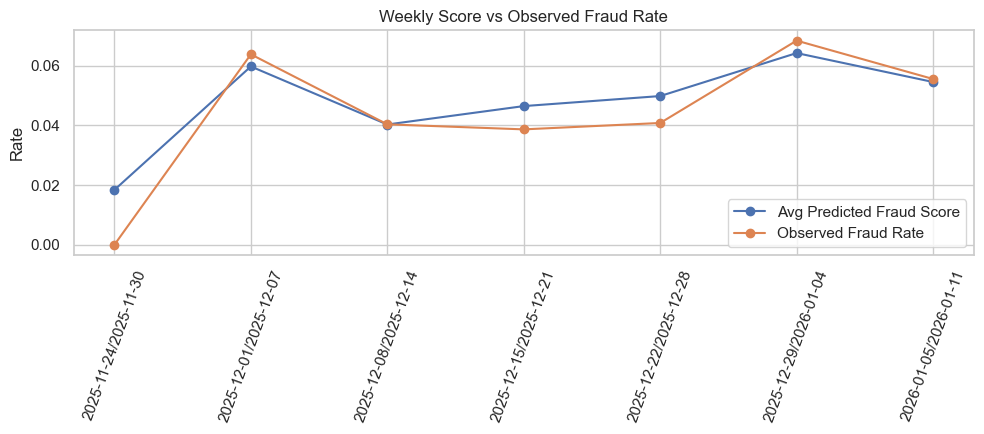

,order_week,avg_score,observed_fraud_rate,volume
2,2025-12-08/2025-12-14,0.040305,0.040359,223
3,2025-12-15/2025-12-21,0.046476,0.038674,181
4,2025-12-22/2025-12-28,0.049840,0.040816,196
5,2025-12-29/2026-01-04,0.064251,0.068421,190
6,2026-01-05/2026-01-11,0.054553,0.055556,18


In [24]:
# Build evaluation frame with order time for trend analysis
eval_frame = model_df.iloc[split_idx:].copy()
eval_frame = eval_frame.assign(
    y_true=y_test.values,
    y_score=best_proba,
)

# Weekly fraud-score and observed fraud rate trends
eval_frame['order_week'] = pd.to_datetime(eval_frame['order_datetime']).dt.to_period('W').astype(str)
weekly = eval_frame.groupby('order_week').agg(
    avg_score=('y_score', 'mean'),
    observed_fraud_rate=('y_true', 'mean'),
    volume=('y_true', 'size'),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(weekly['order_week'], weekly['avg_score'], marker='o', label='Avg Predicted Fraud Score')
ax.plot(weekly['order_week'], weekly['observed_fraud_rate'], marker='o', label='Observed Fraud Rate')
ax.set_title('Weekly Score vs Observed Fraud Rate')
ax.set_ylabel('Rate')
ax.tick_params(axis='x', rotation=70)
ax.legend()
plt.tight_layout()
plt.show()

weekly.tail()


In [25]:
# Simple Population Stability Index (PSI) helper

def compute_psi(expected: pd.Series, actual: pd.Series, bins: int = 10) -> float:
    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()

    quantiles = np.linspace(0, 1, bins + 1)
    cuts = np.unique(np.quantile(expected, quantiles))
    if len(cuts) < 3:
        return np.nan

    exp_counts, _ = np.histogram(expected, bins=cuts)
    act_counts, _ = np.histogram(actual, bins=cuts)

    exp_pct = np.clip(exp_counts / max(exp_counts.sum(), 1), 1e-6, None)
    act_pct = np.clip(act_counts / max(act_counts.sum(), 1), 1e-6, None)

    psi = np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct))
    return float(psi)

# Example drift check: compare training vs holdout score distributions
train_scores = best_est.predict_proba(X_train)[:, 1]
test_scores = best_proba
psi_score = compute_psi(pd.Series(train_scores), pd.Series(test_scores), bins=10)
print('PSI(train_scores vs test_scores):', round(psi_score, 4))
print('Heuristic: <0.1 small drift, 0.1-0.25 moderate, >0.25 significant')


PSI(train_scores vs test_scores): 1.2014
Heuristic: <0.1 small drift, 0.1-0.25 moderate, >0.25 significant


## 12) Advanced Extensions (Ch 19-27)

These are aligned extension tracks to evolve this notebook after the first release.

- **Ch 19 Forecasting:** model weekly fraud volume with time-series methods for staffing capacity.
- **Ch 20 Clustering:** discover fraud typologies (e.g., high-value cross-border + new account).
- **Ch 21-23 NLP:** extract review-text signals (`review_text`) for linguistic fraud cues.
- **Ch 24 Image:** reserve interface for return-image fraud checks when image data exists.
- **Ch 25-26 Recommendation:** build expected user-product affinity, then use deviation as risk feature.
- **Ch 27 Final project polish:** add model card, assumptions, ethics/fairness checks, and reproducibility checklist.


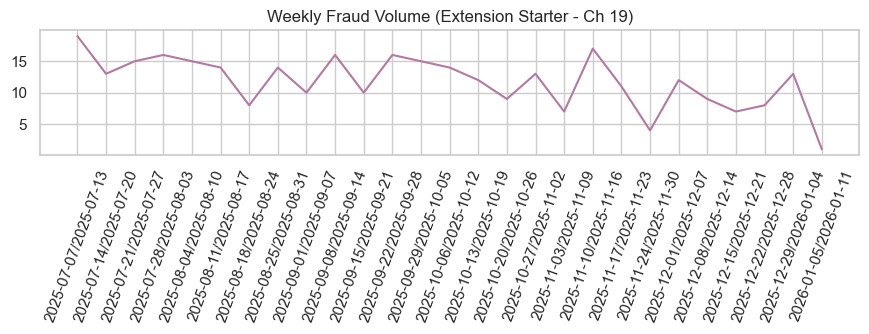

In [26]:
# Example extension starters (optional)

# 1) Forecasting starter
weekly_volume = model_df.groupby(pd.to_datetime(model_df['order_datetime']).dt.to_period('W'))['is_fraud'].sum()
weekly_volume = weekly_volume.rename_axis('week').reset_index(name='fraud_orders')
weekly_volume['week'] = weekly_volume['week'].astype(str)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(weekly_volume['week'], weekly_volume['fraud_orders'], color='#B279A2')
ax.set_title('Weekly Fraud Volume (Extension Starter - Ch 19)')
ax.tick_params(axis='x', rotation=70)
plt.tight_layout()
plt.show()


## Reproducibility Checklist
- Fixed random seed (`42`) for modeling workflows.
- Deterministic feature engineering and column order lock.
- Serialized model bundle in `artifacts/`.
- Temporal holdout used for final report to reduce leakage risk.
- Clear threshold policy with operational bands (`low`, `review`, `block`).
